Used: https://quantum.cloud.ibm.com/docs/en/tutorials/hello-world

Figure 3: Circuit for Swap test: https://arxiv.org/pdf/2003.09187

For returning data: Qiskit provides 2 ways
- you can obtain a probability distribution for a set of qubits you choose to measure
- or you can obtain the expectation value of an observable

In our case, we wanna get the Fidelity.
$$
\text{Fidelity} = F
= \left|\langle \psi \mid \phi \rangle\right|^2
= 2P(0) - 1
$$

$$
\text{Expectation value} = \langle Z \rangle
= P(0) - P(1)
= 2P(0) - 1
= F
$$

So we wanna measure the q0 and get the expectation value, which is our fidelity.

Running on the simulator for now, so using FakeBelemV2 for now 

## Simplest setup: 2 train points, 1 test points, 1 dimension:

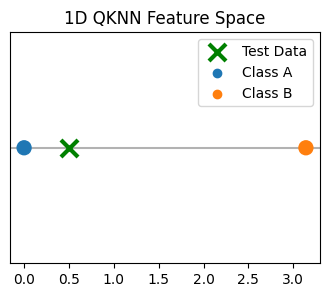

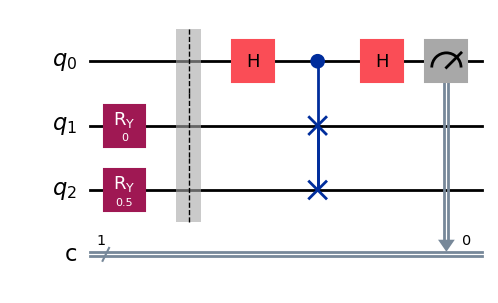

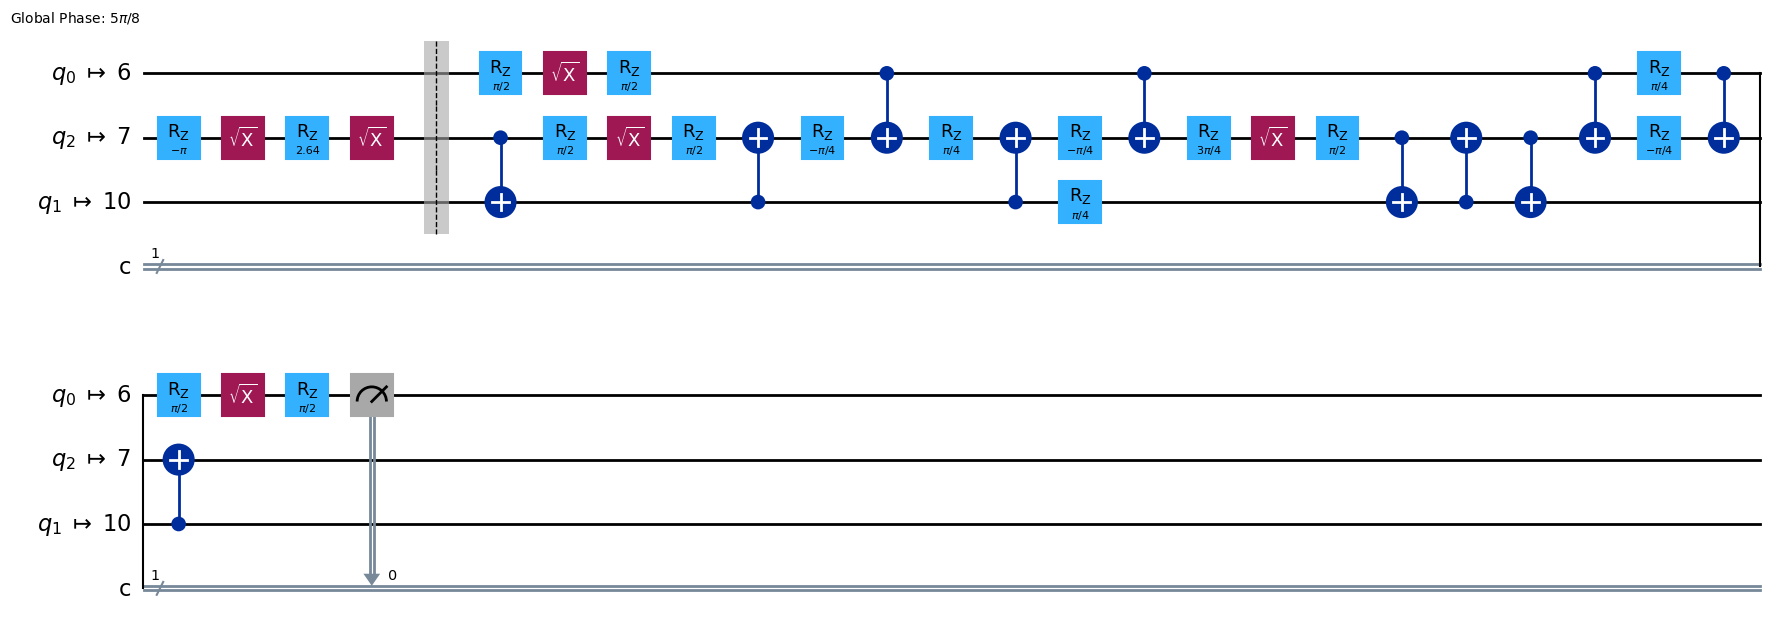

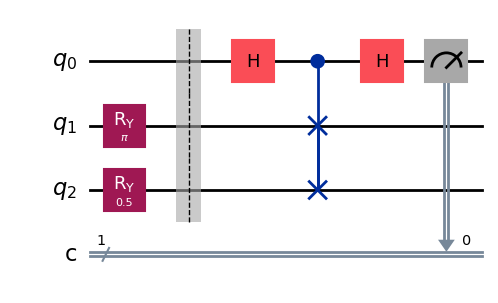

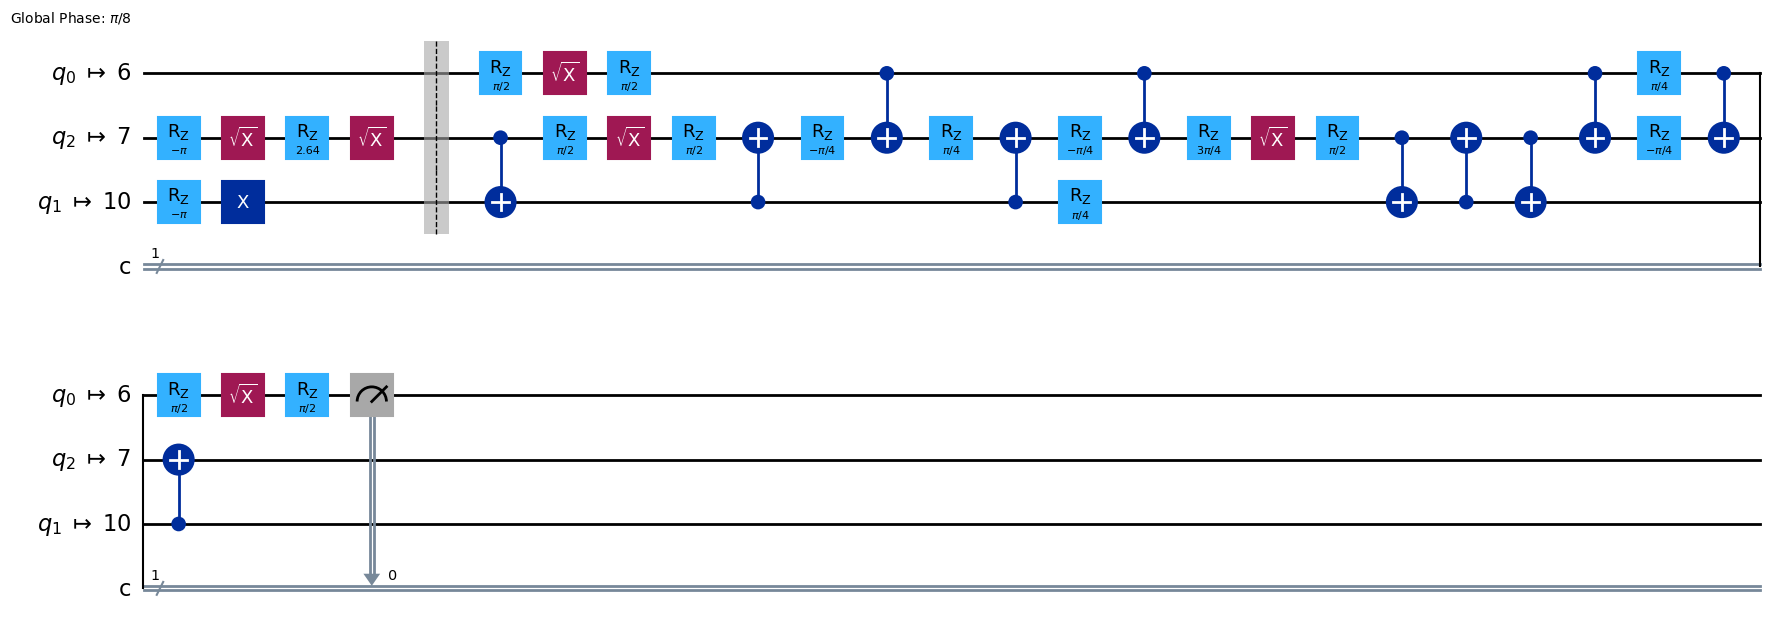

Fidelity Train 1 (Pi): 0.8216
Fidelity Train 2 (0):  0.0732
Prediction: Class A


In [52]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import SparsePauliOp
from qiskit.transpiler import generate_preset_pass_manager
from qiskit_ibm_runtime import EstimatorV2
from qiskit_ibm_runtime.fake_provider import FakeGuadalupeV2 # 16 qubits (for more than 24 we need to install Qiskit air)
import numpy as np
from IPython.display import display
import matplotlib.pyplot as plt
from qiskit import QuantumRegister, ClassicalRegister, qpy
from collections import Counter
from qiskit_aer import AerSimulator
from dataclasses import dataclass
from typing import List, Tuple
from sklearn.datasets import load_iris
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report
from qiskit.quantum_info import random_unitary

def visualize_1d(train_data, train_labels, test_data):
    unique_labels = sorted(list(set(train_labels)))
    cm = plt.get_cmap('tab10')
    color_map = {label: cm(i) for i, label in enumerate(unique_labels)}
    
    plt.figure(figsize=(4, 3))
    plt.axhline(0, color='black', alpha=0.3)
    
    train_x = [pt[0] for pt in train_data]
    test_x = [pt[0] for pt in test_data]
    
    plt.scatter(train_x, np.zeros_like(train_x), 
                c=[color_map[l] for l in train_labels], s=100, zorder=2)
    
    plt.scatter(test_x, np.zeros_like(test_x), 
                c='green', marker='x', s=150, linewidths=3, label='Test Data', zorder=3)
    
    for label, color in color_map.items():
        plt.scatter([], [], c=[color], label=label) 
    
    plt.title("1D QKNN Feature Space")
    plt.ylim(-0.1, 0.1)
    plt.yticks([])
    plt.legend()
    plt.show()

def compute_fidelity_1d(train_val, test_val):
    qc = QuantumCircuit(3, 1) # 1 for ancilla, 1 for 1 dimension train data, 1 for 1 dimension test data
    
    # 1. Encoding
    qc.ry(train_val, 1)
    qc.ry(test_val, 2)
    qc.barrier()
    
    # 2. SWAP Test
    qc.h(0)
    qc.cswap(0, 1, 2)
    qc.h(0)

    qc.measure(0, 0)

    display(qc.draw("mpl"))

    isa = pm.run(qc)
    display(isa.draw("mpl"))
    obs = observable.apply_layout(isa.layout)
    estimator = EstimatorV2(backend)
    job = estimator.run([(isa, obs)], precision=0.01)
    result = job.result()

    return result[0].data.evs

train_points = [0, np.pi]
train_labels = ['Class A', 'Class B']
test_point = 0.5

visualize_1d([np.array([x]) for x in train_points], train_labels, [np.array([test_point])])

backend = FakeGuadalupeV2()
pm = generate_preset_pass_manager(backend=backend, optimization_level=1)
observable = SparsePauliOp("IIZ") # Measure q0

fid1 = compute_fidelity_1d(train_points[0], test_point)
fid2 = compute_fidelity_1d(train_points[1], test_point)

print(f"Fidelity Train 1 (Pi): {fid1:.4f}")
print(f"Fidelity Train 2 (0):  {fid2:.4f}")

label = train_labels[0] if fid1 > fid2 else train_lables[1]
print(f"Prediction: {label}")

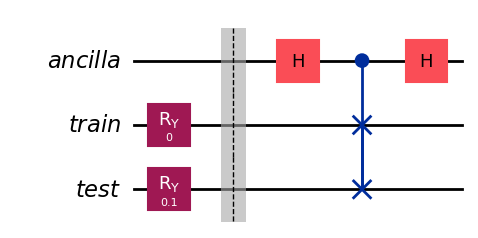

Fidelity(Test 0, Train 0 [Class A]): 0.8672
Fidelity(Test 0, Train 1 [Class B]): 0.0444
Test 0: top k nearest neighbors = ['Class A'] | Prediction: Class A ✅
OVERALL ACCURACY: 100.00%


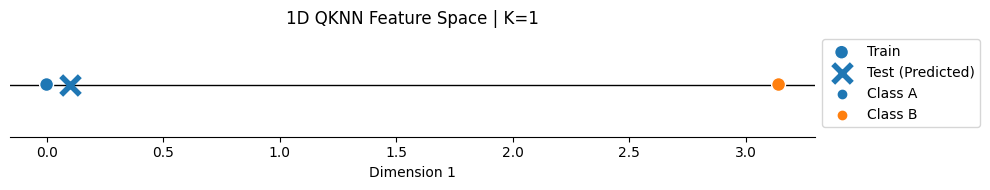

['Class A']

In [ ]:
def visualize_data(train_data, train_labels, test_data, test_predictions, k_value):
    dims = len(train_data[0])
    is_1d = (dims == 1)

    train_x = [pt[0] for pt in train_data]
    test_x  = [pt[0] for pt in test_data]
    train_y = [0 if is_1d else pt[1] for pt in train_data]
    test_y  = [0 if is_1d else pt[1] for pt in test_data]

    if is_1d:
        plt.figure(figsize=(10, 2))
        plt.axhline(0, color='black', linewidth=1, zorder=1)
        plt.yticks([]); plt.ylim(-0.5, 0.5); plt.grid(False)
        for s in ['left', 'right', 'top']: plt.gca().spines[s].set_visible(False)
    else:
        plt.figure(figsize=(8, 6))
        plt.grid(True, linestyle='--', alpha=0.5)
        plt.ylabel("Dimension 2")

    unique_labels = sorted(list(set(train_labels)))
    cm = plt.get_cmap('tab10')
    color_map = {l: cm(i) for i, l in enumerate(unique_labels)}

    plt.scatter(train_x, train_y, s=100, zorder=2, edgecolors='white',
                c=[color_map[l] for l in train_labels], label="Train")
    
    plt.scatter(test_x, test_y, s=180, zorder=3, marker='x', linewidths=4,
                c=[color_map[l] for l in test_predictions], label='Test (Predicted)')

    for label, color in color_map.items():
        plt.scatter([], [], c=[color], label=label)

    proj_text = " (Projection)" if dims > 2 else ""
    plt.title(f"{dims}D QKNN Feature Space{proj_text} | K={k_value}")
    plt.xlabel("Dimension 1")
    plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
    plt.tight_layout()
    plt.show()

@dataclass
class ClassicalInput:
    train: List[np.ndarray]
    test: List[np.ndarray]

@dataclass
class QuantumInput:
    train: List[QuantumCircuit]
    test: List[QuantumCircuit]

QKNNInput = ClassicalInput | QuantumInput

def encode_classical_data(data: np.ndarray) -> QuantumCircuit:
    qc = QuantumCircuit(len(data))
    for i, val in enumerate(data):
        qc.ry(val, i)
    return qc

def get_initialization_circuits(qknn_input: QKNNInput, train_i: int, test_i: int) -> Tuple[QuantumCircuit, QuantumCircuit]:
    match qknn_input:
        case QuantumInput(train, test):
            return train[train_i], test[test_i]
        case ClassicalInput(train, test):
            return encode_classical_data(train[train_i]), encode_classical_data(test[test_i])

def compute_fidelity(train_init, test_init, show_circuit, backend):
    n_qubits = max(train_init.num_qubits, test_init.num_qubits)
    
    ancilla = QuantumRegister(1, name="ancilla")
    reg_a = QuantumRegister(n_qubits, name="train")
    reg_b = QuantumRegister(n_qubits, name="test")
    qc = QuantumCircuit(ancilla, reg_a, reg_b)

    # 1. State Preparation
    qc.compose(train_init, qubits=reg_a, inplace=True)
    qc.compose(test_init, qubits=reg_b, inplace=True)
    qc.barrier()

    # 2. SWAP Test
    qc.h(ancilla)
    for i in range(n_qubits):
        qc.cswap(ancilla[0], reg_a[i], reg_b[i])
    qc.h(ancilla)

    if show_circuit:
        display(qc.draw("mpl"))

    observable = SparsePauliOp("I" * (2 * n_qubits) + "Z") 
    pm = generate_preset_pass_manager(backend=backend, optimization_level=1)
    isa_circuit = pm.run(qc)
    isa_observable = observable.apply_layout(isa_circuit.layout)
    estimator = EstimatorV2(mode=backend)
    job = estimator.run([(isa_circuit, isa_observable)])
    result = job.result()[0].data.evs
    
    return float(result)

def qknn(qknn_input: QKNNInput, train_labels, K=1, test_labels=None, backend=FakeGuadalupeV2(), show_circuit=True):        
    predictions = []
    num_test = len(qknn_input.test)
    num_train = len(qknn_input.train)

    for i in range(num_test):
        fidelities = []
        for j in range(num_train):
            train_qc, test_qc = get_initialization_circuits(qknn_input, j, i)
            
            fid = compute_fidelity(train_qc, test_qc, show_circuit, backend)
            show_circuit = False 
            
            fidelities.append((fid, train_labels[j]))
            print(f"Fidelity(Test {i}, Train {j} [{train_labels[j]}]): {fid:.4f}")

        fidelities.sort(key=lambda x: x[0], reverse=True)
        top_k_labels = [label for fid, label in fidelities[:K]]
        prediction = Counter(top_k_labels).most_common(1)[0][0]
        predictions.append(prediction)
        
        status = ""
        if test_labels is not None:
            if prediction == test_labels[i]:
                status = " ✅"
            else:
                status = f" - Actual: {test_labels[i]} ❌"
        
        print(f"Test {i}: top k nearest neighbors = {top_k_labels} | Prediction: {prediction}{status}")

    if test_labels is not None:
        correct = sum(1 for p, a in zip(predictions, test_labels) if p == a)
        print(f"OVERALL ACCURACY: {(correct/num_test)*100:.2f}%")

    if isinstance(qknn_input, ClassicalInput):
        visualize_data(qknn_input.train, train_labels, qknn_input.test, predictions, K)

    return predictions

train_data = [np.array([0.0]), np.array([np.pi])] 
train_labels = ["Class A", "Class B"]
test_labels = ["Class A"]
test_data = [np.array([0.1])]

qknn(ClassicalInput(train=train_data, test=test_data), train_labels, test_labels=test_labels)

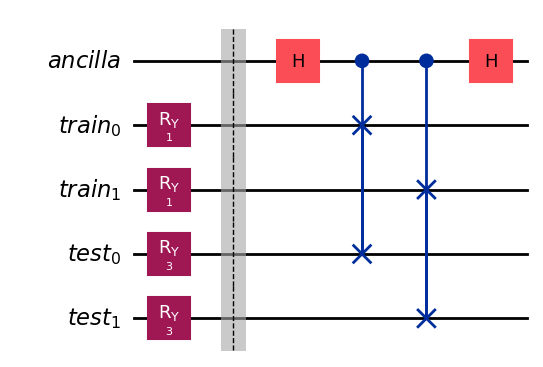

Fidelity(Test 0, Train 0 [Class A]): 0.1177
Fidelity(Test 0, Train 1 [Class A]): 0.6753
Fidelity(Test 0, Train 2 [Class B]): 0.5298
Fidelity(Test 0, Train 3 [Class B]): 0.0947
Test 0: top k nearest neighbors = ['Class A'] | Prediction: Class A
Fidelity(Test 1, Train 0 [Class A]): 0.0381
Fidelity(Test 1, Train 1 [Class A]): 0.2881
Fidelity(Test 1, Train 2 [Class B]): 0.6763
Fidelity(Test 1, Train 3 [Class B]): 0.2295
Test 1: top k nearest neighbors = ['Class B'] | Prediction: Class B


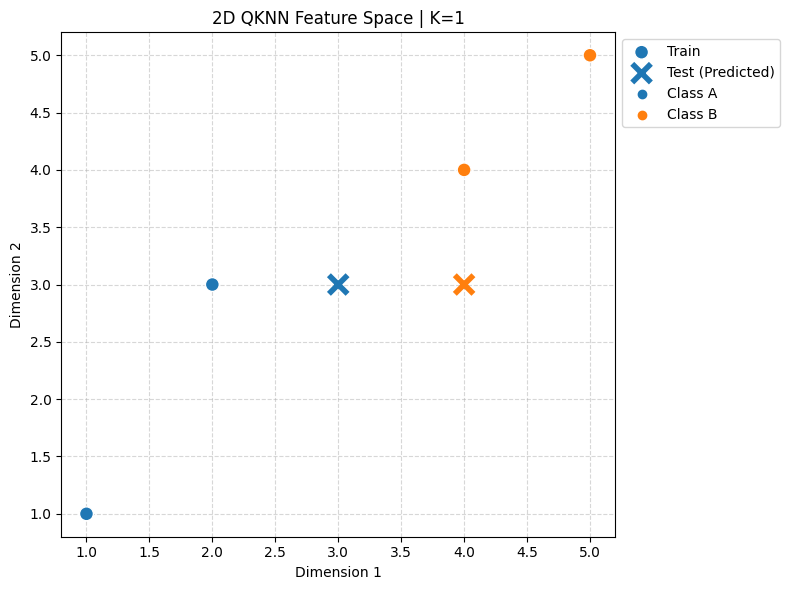

['Class A', 'Class B']

In [3]:
train_data_2d = [
    np.array([1, 1]),
    np.array([2, 3]),
    np.array([4, 4]),
    np.array([5, 5])
]
train_labels_2d = ["Class A", "Class A", "Class B", "Class B"]

test_data_2d = [np.array([3, 3]), np.array([4, 3])]

qknn(ClassicalInput(train=train_data_2d, test=test_data_2d), train_labels_2d)

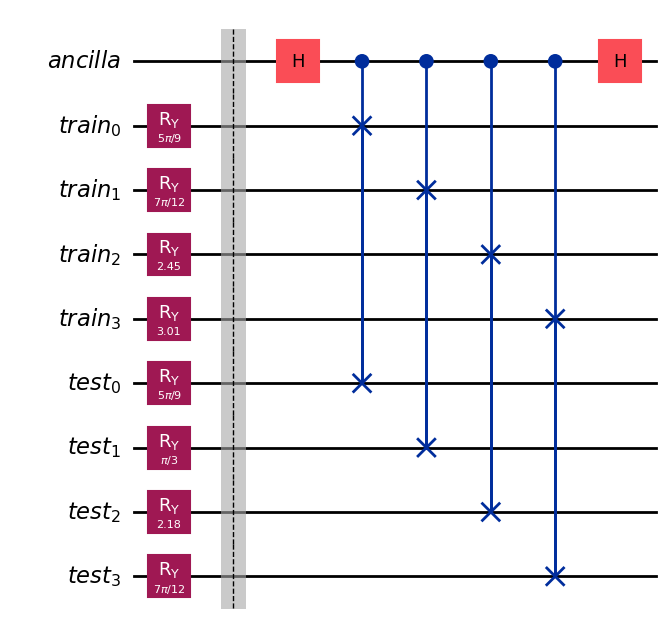

Fidelity(Test 0, Train 0 [virginica]): 0.3525
Fidelity(Test 0, Train 1 [setosa]): 0.0874
Fidelity(Test 0, Train 2 [virginica]): 0.5547
Fidelity(Test 0, Train 3 [versicolor]): 0.4141
Fidelity(Test 0, Train 4 [setosa]): 0.0601
Fidelity(Test 0, Train 5 [setosa]): 0.0684
Fidelity(Test 0, Train 6 [setosa]): 0.0630
Fidelity(Test 0, Train 7 [virginica]): 0.5444
Fidelity(Test 0, Train 8 [setosa]): 0.0830
Fidelity(Test 0, Train 9 [setosa]): 0.0669
Fidelity(Test 0, Train 10 [versicolor]): 0.5762
Fidelity(Test 0, Train 11 [setosa]): 0.0464
Fidelity(Test 0, Train 12 [versicolor]): 0.3398
Fidelity(Test 0, Train 13 [versicolor]): 0.4526
Fidelity(Test 0, Train 14 [virginica]): 0.5303
Fidelity(Test 0, Train 15 [virginica]): 0.5674
Fidelity(Test 0, Train 16 [setosa]): 0.0278
Fidelity(Test 0, Train 17 [setosa]): 0.0513
Fidelity(Test 0, Train 18 [virginica]): 0.4624
Fidelity(Test 0, Train 19 [setosa]): 0.0728
Fidelity(Test 0, Train 20 [virginica]): 0.4199
Fidelity(Test 0, Train 21 [setosa]): 0.0640
Fidel

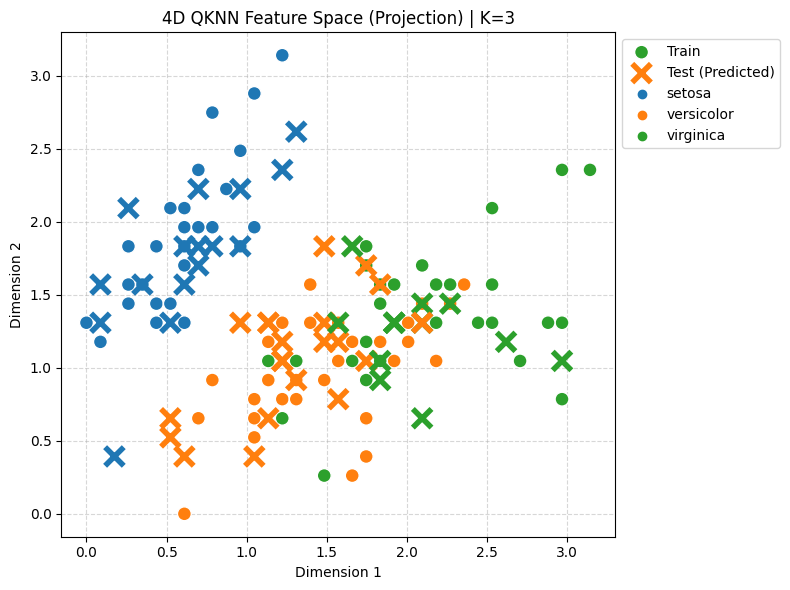

[np.str_('versicolor'),
 np.str_('versicolor'),
 np.str_('setosa'),
 np.str_('versicolor'),
 np.str_('virginica'),
 np.str_('versicolor'),
 np.str_('versicolor'),
 np.str_('setosa'),
 np.str_('versicolor'),
 np.str_('versicolor'),
 np.str_('setosa'),
 np.str_('setosa'),
 np.str_('setosa'),
 np.str_('setosa'),
 np.str_('setosa'),
 np.str_('virginica'),
 np.str_('versicolor'),
 np.str_('versicolor'),
 np.str_('virginica'),
 np.str_('versicolor'),
 np.str_('virginica'),
 np.str_('versicolor'),
 np.str_('setosa'),
 np.str_('virginica'),
 np.str_('setosa'),
 np.str_('virginica'),
 np.str_('virginica'),
 np.str_('setosa'),
 np.str_('setosa'),
 np.str_('virginica'),
 np.str_('virginica'),
 np.str_('virginica'),
 np.str_('setosa'),
 np.str_('versicolor'),
 np.str_('setosa'),
 np.str_('setosa'),
 np.str_('virginica'),
 np.str_('versicolor'),
 np.str_('versicolor'),
 np.str_('versicolor'),
 np.str_('versicolor'),
 np.str_('versicolor'),
 np.str_('setosa'),
 np.str_('setosa'),
 np.str_('versicolo

In [4]:
iris = load_iris()
X = iris.data  # The 4 features
y = iris.target # The labels (0, 1, 2)
target_names = iris.target_names # ['setosa', 'versicolor', 'virginica']

# 2. IMPORTANT: Normalize to [0, Pi] for Quantum RY gates
# If you don't scale, values like 7.9 will over-rotate the qubits!
scaler = MinMaxScaler(feature_range=(0, np.pi))
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, train_size=100, test_size=50, random_state=42, stratify=y
)

train_labels = [target_names[i] for i in y_train]
test_labels_actual = [target_names[i] for i in y_test]

train_data = [np.array(pt) for pt in X_train]
test_data = [np.array(pt) for pt in X_test]

qknn(ClassicalInput(train=train_data, test=test_data), train_labels, test_labels=test_labels_actual, K=3)

In [7]:
k_val = 3
knn_classical = KNeighborsClassifier(n_neighbors=k_val)

knn_classical.fit(X_train, y_train)
y_pred_classical = knn_classical.predict(X_test)

acc_classical = accuracy_score(y_test, y_pred_classical)

print(f"Accuracy: {acc_classical * 100:.2f}%")
print("\nDetailed Report:")
print(classification_report(y_test, y_pred_classical, target_names=target_names))

Accuracy: 94.00%

Detailed Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        16
  versicolor       0.85      1.00      0.92        17
   virginica       1.00      0.82      0.90        17

    accuracy                           0.94        50
   macro avg       0.95      0.94      0.94        50
weighted avg       0.95      0.94      0.94        50



In [5]:
def get_entanglement_states():
    abc_sep = QuantumCircuit(3)
    
    ab_c = QuantumCircuit(3)
    ab_c.h(0); ab_c.cx(0, 1)
    
    a_bc = QuantumCircuit(3)
    a_bc.h(1); a_bc.cx(1, 2)
    
    ac_b = QuantumCircuit(3)
    ac_b.h(0); ac_b.cx(0, 2)
    
    abc_ghz = QuantumCircuit(3)
    abc_ghz.h(0); abc_ghz.cx(0, 1); abc_ghz.cx(1, 2)
    
    return [abc_sep, ab_c, a_bc, ac_b, abc_ghz]

labels = ['A-B-C', 'AB-C', 'A-BC', 'AC-B', 'ABC']
circuits = get_entanglement_states()

qknn(
    qknn_input=QuantumInput(
    train=circuits,
    test=circuits
    ), 
    train_labels=labels, 
    test_labels=labels,
    show_circuit=False
)

Fidelity(Test 0, Train 0 [A-B-C]): 0.6865
Fidelity(Test 0, Train 1 [AB-C]): 0.3574
Fidelity(Test 0, Train 2 [A-BC]): 0.3506
Fidelity(Test 0, Train 3 [AC-B]): 0.3564
Fidelity(Test 0, Train 4 [ABC]): 0.3403
Test 0: top k nearest neighbors = ['A-B-C'] | Prediction: A-B-C ✅
Fidelity(Test 1, Train 0 [A-B-C]): 0.3779
Fidelity(Test 1, Train 1 [AB-C]): 0.6846
Fidelity(Test 1, Train 2 [A-BC]): 0.2104
Fidelity(Test 1, Train 3 [AC-B]): 0.2061
Fidelity(Test 1, Train 4 [ABC]): 0.1997
Test 1: top k nearest neighbors = ['AB-C'] | Prediction: AB-C ✅
Fidelity(Test 2, Train 0 [A-B-C]): 0.3989
Fidelity(Test 2, Train 1 [AB-C]): 0.1611
Fidelity(Test 2, Train 2 [A-BC]): 0.6689
Fidelity(Test 2, Train 3 [AC-B]): 0.1758
Fidelity(Test 2, Train 4 [ABC]): 0.1919
Test 2: top k nearest neighbors = ['A-BC'] | Prediction: A-BC ✅
Fidelity(Test 3, Train 0 [A-B-C]): 0.3779
Fidelity(Test 3, Train 1 [AB-C]): 0.2144
Fidelity(Test 3, Train 2 [A-BC]): 0.2334
Fidelity(Test 3, Train 3 [AC-B]): 0.6230
Fidelity(Test 3, Train 4 [

['A-B-C', 'AB-C', 'A-BC', 'AC-B', 'ABC']

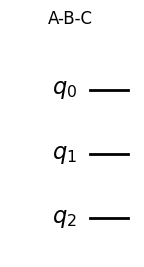

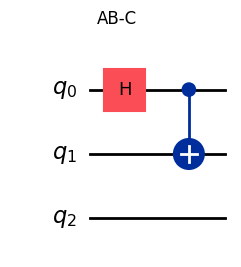

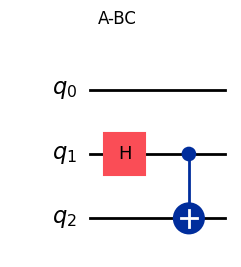

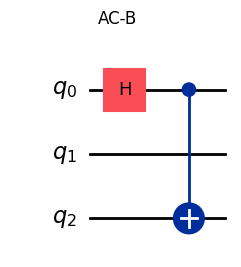

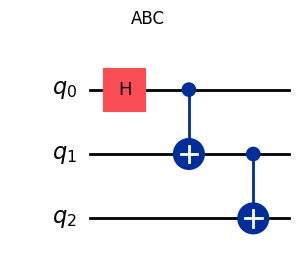

In [62]:
for label, qc in zip(labels, circuits):
    fig = qc.draw(output='mpl')
    fig.suptitle(label)
    display(fig)

In [47]:
sweep_values = [0.7, 0.8, 0.9, 1, 1.5, 2, 2.5, 3.14]

for amount in sweep_values:
    print(f"\n" + "="*50)
    print(f"TESTING STABILITY AT: {amount} Radians (~{int(np.degrees(amount))}°)")
    print("="*50)
    
    test_circuits = []
    test_labels = []
    
    for i, qc in enumerate(circuits):
        for _ in range(20):
            t_qc = qc.copy()
            for q in range(3):
                t_qc.rx(np.random.uniform(-amount, amount), q)
                t_qc.rz(np.random.uniform(-amount, amount), q)
            
            test_circuits.append(t_qc)
            test_labels.append(labels[i])

    qknn(
        qknn_input=QuantumInput(train=circuits, test=test_circuits), 
        train_labels=labels, 
        test_labels=test_labels,
        show_circuit=False
    )


TESTING STABILITY AT: 0.7 Radians (~40°)
Fidelity(Test 0, Train 0 [A-B-C]): 0.6743
Fidelity(Test 0, Train 1 [AB-C]): 0.3335
Fidelity(Test 0, Train 2 [A-BC]): 0.3477
Fidelity(Test 0, Train 3 [AC-B]): 0.3267
Fidelity(Test 0, Train 4 [ABC]): 0.3120
Test 0: top k nearest neighbors = ['A-B-C'] | Prediction: A-B-C ✅
Fidelity(Test 1, Train 0 [A-B-C]): 0.6514
Fidelity(Test 1, Train 1 [AB-C]): 0.3140
Fidelity(Test 1, Train 2 [A-BC]): 0.3501
Fidelity(Test 1, Train 3 [AC-B]): 0.3506
Fidelity(Test 1, Train 4 [ABC]): 0.3496
Test 1: top k nearest neighbors = ['A-B-C'] | Prediction: A-B-C ✅
Fidelity(Test 2, Train 0 [A-B-C]): 0.6729
Fidelity(Test 2, Train 1 [AB-C]): 0.3604
Fidelity(Test 2, Train 2 [A-BC]): 0.3442
Fidelity(Test 2, Train 3 [AC-B]): 0.3530
Fidelity(Test 2, Train 4 [ABC]): 0.3276
Test 2: top k nearest neighbors = ['A-B-C'] | Prediction: A-B-C ✅
Fidelity(Test 3, Train 0 [A-B-C]): 0.6440
Fidelity(Test 3, Train 1 [AB-C]): 0.3008
Fidelity(Test 3, Train 2 [A-BC]): 0.3765
Fidelity(Test 3, Trai

In [16]:
binary_labels = ['Separable', 'Entangled', 'Entangled', 'Entangled', 'Entangled']
circuits = get_entanglement_states()

qknn(
    qknn_input=QuantumInput(
        train=circuits,
        test=circuits
    ), 
    train_labels=binary_labels, 
    test_labels=binary_labels,
    K=1, 
    show_circuit=False
)

Fidelity(Test 0, Train 0 [Separable]): 0.7300
Fidelity(Test 0, Train 1 [Entangled]): 0.3394
Fidelity(Test 0, Train 2 [Entangled]): 0.3779
Fidelity(Test 0, Train 3 [Entangled]): 0.3867
Fidelity(Test 0, Train 4 [Entangled]): 0.3491
Test 0: top k nearest neighbors = ['Separable'] | Prediction: Separable ✅
Fidelity(Test 1, Train 0 [Separable]): 0.4106
Fidelity(Test 1, Train 1 [Entangled]): 0.6113
Fidelity(Test 1, Train 2 [Entangled]): 0.1797
Fidelity(Test 1, Train 3 [Entangled]): 0.1914
Fidelity(Test 1, Train 4 [Entangled]): 0.1919
Test 1: top k nearest neighbors = ['Entangled'] | Prediction: Entangled ✅
Fidelity(Test 2, Train 0 [Separable]): 0.3765
Fidelity(Test 2, Train 1 [Entangled]): 0.1880
Fidelity(Test 2, Train 2 [Entangled]): 0.6587
Fidelity(Test 2, Train 3 [Entangled]): 0.2017
Fidelity(Test 2, Train 4 [Entangled]): 0.1772
Test 2: top k nearest neighbors = ['Entangled'] | Prediction: Entangled ✅
Fidelity(Test 3, Train 0 [Separable]): 0.4082
Fidelity(Test 3, Train 1 [Entangled]): 0.2

['Separable', 'Entangled', 'Entangled', 'Entangled', 'Entangled']

In [26]:
# Load gate W representing the train states and the list with corresponding entanglement classes
with open("W_gate list.qpy", "rb") as handle:

    qc_train = qpy.load(handle)

labels_train = np.load("Class list 2.npy")   

# Load the V gates representing the test states and the list with corresponding entanglement classes
with open("V_gate list.qpy", "rb") as handle:
    qc_test = qpy.load(handle)

labels_test = np.load("Class list test.npy")

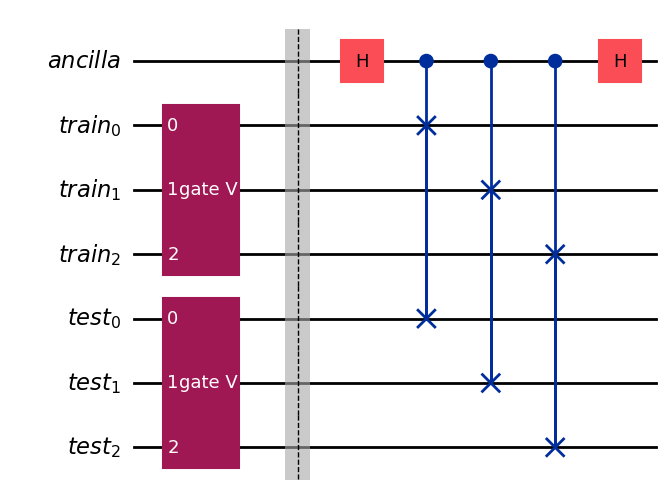

Fidelity(Test 0, Train 0 [0.0]): 0.2334
Fidelity(Test 0, Train 1 [1.0]): 0.0723
Fidelity(Test 0, Train 2 [1.0]): 0.1714
Fidelity(Test 0, Train 3 [1.0]): 0.1025
Fidelity(Test 0, Train 4 [0.0]): 0.0449
Fidelity(Test 0, Train 5 [0.0]): 0.0205
Fidelity(Test 0, Train 6 [0.0]): 0.1558
Fidelity(Test 0, Train 7 [0.0]): 0.1123
Fidelity(Test 0, Train 8 [1.0]): 0.1802
Fidelity(Test 0, Train 9 [0.0]): 0.0771
Fidelity(Test 0, Train 10 [0.0]): 0.0337
Fidelity(Test 0, Train 11 [0.0]): 0.0518
Fidelity(Test 0, Train 12 [1.0]): 0.1855
Fidelity(Test 0, Train 13 [0.0]): 0.0479
Fidelity(Test 0, Train 14 [1.0]): 0.0474
Fidelity(Test 0, Train 15 [1.0]): 0.0850
Fidelity(Test 0, Train 16 [0.0]): 0.1353
Fidelity(Test 0, Train 17 [1.0]): 0.1587
Fidelity(Test 0, Train 18 [1.0]): 0.0894
Fidelity(Test 0, Train 19 [0.0]): 0.1128
Fidelity(Test 0, Train 20 [0.0]): 0.1094
Fidelity(Test 0, Train 21 [1.0]): 0.0483
Fidelity(Test 0, Train 22 [1.0]): 0.1304
Fidelity(Test 0, Train 23 [0.0]): 0.0405
Fidelity(Test 0, Train 24 

[np.float64(1.0),
 np.float64(1.0),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(1.0),
 np.float64(0.0),
 np.float64(1.0),
 np.float64(1.0),
 np.float64(0.0),
 np.float64(1.0),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(1.0),
 np.float64(1.0),
 np.float64(0.0),
 np.float64(1.0),
 np.float64(1.0),
 np.float64(0.0),
 np.float64(1.0),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(0.0),
 np.float64(1.0),
 np.float64(1.0),
 np.float64(1.0)]

In [30]:
qknn(
    qknn_input=QuantumInput(
    train= qc_train,
    test = qc_test
    ), 
    train_labels=labels_train, 
    test_labels=labels_test,
    K=11
)